In [1]:
import sys, os, json, time
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize, minimize_scalar

from tcr_pipeline.normalization import tmm_normalize
from tcr_pipeline import nb_glm as nb

import pyreadr

In [2]:
TEST_PIDS    = ["BR054", "BR037"]                         # patients to test
EXCLUDE_SAMPLES = []          # e.g. [("HDBR06_SEQTR_ReSeq", 21)] after QC in cell 3
N_JOBS       = 8              # parallel workers for the trajectory test
MIN_DETECT_DISP = 2           # detections per clone for dispersion fitting
MIN_DETECT_TEST = 3           # detections per clone for the slope test
ALPHA        = 0.05
N_V2         = 3000           # clones per design in the missing-data comparison
N_V3         = 4000           # clones per patient in the end-to-end test
OUT_DIR      = "../results/nb_v2"

In [3]:
healthy_raw = pd.read_csv("../data/healthy_raw.csv", index_col=0)
patients_raw = pd.read_csv("../data/patients_raw.csv", index_col=0)

In [4]:
patients_raw = patients_raw[
    patients_raw['patient'].isin(TEST_PIDS)]

In [5]:
healthy_post = pd.read_csv("../data/Healthy-Data-long.csv")

In [6]:
from tcr_pipeline.data_io import long_df_to_wide

wide_post = long_df_to_wide(healthy_post)

In [7]:
wide_raw = long_df_to_wide(healthy_raw)

In [8]:
def sample_table(d):
    g = d.groupby(['patient', 'day'])
    t = g.agg(D_t=('D_t', 'first'), lib_post=('lib_post', 'first'),
              c_t=('c_t', 'first'), n_clones=('clono', 'size'),
              top_clone_freq=('freq_in', 'max'))
    t['removed_frac'] = 1 - t['lib_post'] / t['D_t']
    t['n_at_cutoff'] = g.apply(lambda s: int((s['count'] == s['c_t']).sum()))
    t['top_clone_freq'] = t['top_clone_freq'] / 100
    return t

samples_h = sample_table(healthy_raw)
samples_p = sample_table(patients_raw)
display(samples_h.round(4))
display(samples_p.round(4))

D_t  lib_post   c_t  n_clones  top_clone_freq  \
patient            day                                                         
HD106_SEQTR        0    20776057.0  19064838  21.0    191146          0.0109   
                   46   20271816.0  18814334  21.0    166686          0.0118   
                   82   13155700.0  11923023  14.0    196560          0.0098   
                   131  16998893.0  14866483  17.0    213759          0.0088   
HD197_SEQTR        0    16017072.0  13598350  17.0    213417          0.0064   
                   46   15062825.0  12942781  16.0    189060          0.0111   
                   82   17667150.0  16076784  18.0    179473          0.0093   
                   131  17706840.0  15864008  18.0    184846          0.0077   
HDBR01_SEQTR_ReSeq 0    10155538.0   9797482  11.0    101763          0.0032   
                   21   12854243.0  12286013  13.0    133280          0.0030   
                   42   21302289.0  20439637  22.0    109420          0.0026   
                   126  13816805.0  13264378  14.0    115549          0.0029   
HDBR02_SEQTR_ReSeq 0     5380856.0   5207497   6.0     87988          0.1940   
                   48    8857000.0   8690147   9.0     53280          0.1563   
                   71    6669562.0   6384434   7.0     93623          0.2588   
HDBR03_SEQTR_ReSeq 0    10650237.0  10393489  11.0     71638          0.0377   
                   21    4888783.0   4643232   5.0    157045          0.0410   
                   35    6397513.0   6206839   7.0    100372          0.0293   
                   66    5034447.0   4832580   6.0    118041          0.0209   
                   84    5390104.0   5176791   6.0     98678          0.0167   
HDBR06_SEQTR_ReSeq 0    10704506.0  10547250  11.0     43115          0.0458   
                   21    5073105.0   5069548   6.0       706          0.2425   
                   82   11483748.0  11209119  12.0     65536          0.0411   
                   105  10809851.0  10440607  11.0     85011          0.0359   

                        removed_frac  n_at_cutoff  
patient            day                             
HD106_SEQTR        0          0.0824         4479  
                   46         0.0719         3717  
                   82         0.0937         8096  
                   131        0.1254         8492  
HD197_SEQTR        0          0.1510         9626  
                   46         0.1407         9165  
                   82         0.0900         5585  
                   131        0.1041         5972  
HDBR01_SEQTR_ReSeq 0          0.0353         2760  
                   21         0.0442         3304  
                   42         0.0405         1489  
                   126        0.0400         2344  
HDBR02_SEQTR_ReSeq 0          0.0322         6222  
                   48         0.0188         1910  
                   71         0.0428         7165  
HDBR03_SEQTR_ReSeq 0          0.0241         1904  
                   21         0.0502        15346  
                   35         0.0298         4373  
                   66         0.0401         7887  
                   84         0.0396         5714  
HDBR06_SEQTR_ReSeq 0          0.0147          979  
                   21         0.0007           83  
                   82         0.0239         1516  
                   105        0.0342         2362

D_t  lib_post   c_t  n_clones  top_clone_freq  \
patient day                                                         
BR037   0     5198802.0   4883559   6.0     88873          0.0048   
        28    3278684.0   3123716   4.0    123647          0.0488   
        119   4587433.0   4391807   5.0     67530          0.0037   
        189   6536904.0   6244275   7.0     44655          0.0041   
        218   5843098.0   5491121   6.0     78871          0.0037   
        364   8673209.0   8422731   9.0     72570          0.0038   
BR054   0     5352048.0   5151362   6.0     99188          0.0272   
        19   11294031.0  10356050  12.0    154386          0.0250   
        68    5067147.0   4738367   6.0    105314          0.0202   
        141   2926693.0   2901235   3.0     30093          0.1914   
        187   4155331.0   3975392   5.0     84805          0.0188   
        327   4411067.0   4296450   5.0     30551          0.0259   

             removed_frac  n_at_cutoff  
patient day                             
BR037   0          0.0606         5795  
        28         0.0473        12489  
        119        0.0426         6341  
        189        0.0448         4068  
        218        0.0602         6609  
        364        0.0289         1965  
BR054   0          0.0375         5080  
        19         0.0831         6022  
        68         0.0649         7874  
        141        0.0087         5543  
        187        0.0433         6198  
        327        0.0260         4385

In [8]:
healthy_raw_tmm = tmm_normalize(healthy_raw)

In [9]:
import tcr_pipeline.dispersion_experiments as dx
import tcr_pipeline.nb_glm_legacy as nb_legacy
# 1. Inputs: sparse donor data with lib (= D_t * tmm) and the per-sample threshold c
d = nb.attach_offset(healthy_raw_tmm)
c_t = (d[d['count'] > 0].groupby(['patient', 'day'])['count']
       .min().rename('c').reset_index())
d = d.merge(c_t, on=['patient', 'day'])

HD106_SEQTR            S3 CR        phi=2.985  2s
HD106_SEQTR            S4 CR+trunc  phi=0.021  102s
HD197_SEQTR            S3 CR        phi=3.683  2s
HD197_SEQTR            S4 CR+trunc  phi=0.937  122s
HDBR01_SEQTR_ReSeq     S3 CR        phi=2.034  1s
HDBR01_SEQTR_ReSeq     S4 CR+trunc  phi=0.758  53s
HDBR02_SEQTR_ReSeq     S3 CR        phi=2.535  1s
HDBR02_SEQTR_ReSeq     S4 CR+trunc  phi=0.774  34s
HDBR03_SEQTR_ReSeq     S3 CR        phi=2.478  2s
HDBR03_SEQTR_ReSeq     S4 CR+trunc  phi=0.541  83s
HDBR06_SEQTR_ReSeq     S3 CR        phi=1.858  1s
HDBR06_SEQTR_ReSeq     S4 CR+trunc  phi=0.951  21s
                   n_clones                phi            
step                  S3 CR S4 CR+trunc  S3 CR S4 CR+trunc
patient                                                   
HD106_SEQTR           56441       56441  2.985       0.021
HD197_SEQTR           65848       65848  3.683       0.937
HDBR01_SEQTR_ReSeq    34567       34567  2.034       0.758
HDBR02_SEQTR_ReSeq    27761       2776

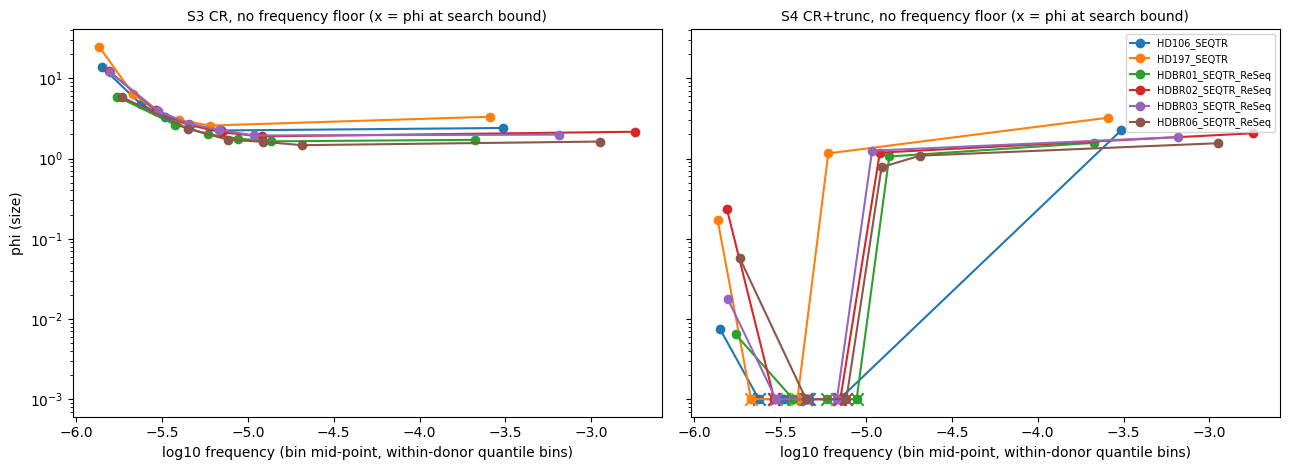

In [12]:
import time, warnings
from pathlib import Path
import matplotlib.pyplot as plt
Path('results').mkdir(exist_ok=True)

STEPS = {'S3 CR':       dict(cox_reid=True, resolve_mean=True, truncate=False),
         'S4 CR+trunc': dict(cox_reid=True, resolve_mean=True, truncate=True)}
N_BINS = 6

glob_rows, bin_rows = [], []
for pat, sub in d.groupby('patient'):
    for step, flags in STEPS.items():
        t0 = time.time()
        with warnings.catch_warnings(), np.errstate(all='ignore'):
            warnings.simplefilter('ignore')
            r = nb.fit_nb_dispersion_cr(sub, n_bins=N_BINS, min_freq_mult=0.0, **flags)
        glob_rows.append({'patient': pat, 'step': step, 'phi': r['phi'],
                          'at_bound': r['phi_at_bound'], 'n_clones': r['n_clones'],
                          'seconds': round(time.time() - t0, 1)})
        b = r['bins'].assign(patient=pat, step=step)
        b['mid_log10_freq'] = b['bin_log10_freq'].map(dx._bin_mid)
        bin_rows.append(b)
        print(f"{pat:22s} {step:12s} phi={r['phi']:.3f}  {time.time() - t0:.0f}s", flush=True)
    # save after each donor, so nothing is lost if it's interrupted
    pd.DataFrame(glob_rows).to_csv('results/donor_bins_global.csv', index=False)
    pd.concat(bin_rows, ignore_index=True).to_csv('results/donor_bins_bins.csv', index=False)

glob_db = pd.DataFrame(glob_rows)
bins_db = pd.concat(bin_rows, ignore_index=True)
bins_db['bin_rank'] = bins_db.groupby(['patient', 'step'])['mid_log10_freq'].rank().astype(int)

# tables
print(glob_db.pivot_table(index='patient', columns='step', values=['phi', 'n_clones']).round(3))
wide = bins_db.pivot_table(index=['patient', 'bin_rank'], columns='step',
                           values=['phi', 'mid_log10_freq', 'n_clones']).round(3)
print(wide)
wide.to_csv('results/donor_bins_wide.csv')

# figure: one panel per method, one line per donor
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, step in zip(axes, STEPS):
    for pat, g in bins_db[bins_db['step'] == step].groupby('patient'):
        g = g.sort_values('mid_log10_freq')
        line, = ax.plot(g['mid_log10_freq'], g['phi'], marker='o', label=pat)
        hit = g[g['at_bound']]
        ax.scatter(hit['mid_log10_freq'], hit['phi'], marker='x', s=80, color=line.get_color())
    ax.set_yscale('log')
    ax.set_title(f'{step}, no frequency floor (x = phi at search bound)', fontsize=10)
    ax.set_xlabel('log10 frequency (bin mid-point, within-donor quantile bins)')
axes[0].set_ylabel('phi (size)')
axes[1].legend(fontsize=7)
fig.tight_layout()
fig.savefig('results/donor_bins_S3_S4.png', dpi=150, bbox_inches='tight')

In [11]:
from tcr_pipeline.nb_glm import nb_trajectory_test_censored
rows = []
for held in d['patient'].unique():
    phi_ref = nb.fit_nb_dispersion_cr(d[d['patient'] != held], truncate=False, min_freq_mult=10)['phi']
    test_df = d[d['patient'] == held]                           # grid-complete as you do for patients
    r = nb_trajectory_test_censored(test_df, phi=phi_ref)          # <- your censored test
    rows.append(r.assign(held_out=held, phi_ref=phi_ref))
cal = pd.concat(rows)
print(cal.columns.tolist())      # check the key and p-value column names first

# pooled observed frequency per clone, over its detected rows (same as the fit's p_depth)
det = d[d['count'] > 0]
abund = (det.groupby(['patient', 'clono'])
            .agg(sum_count=('count', 'sum'), sum_depth=('D_t', 'sum'), n_det=('day', 'size'))
            .reset_index())
abund['log10_freq'] = np.log10(abund['sum_count'] / abund['sum_depth'])

cal2 = cal.merge(abund, on=['patient', 'clono'], how='left')
print('unmatched clones:', cal2['log10_freq'].isna().sum())

cal2['abund_bin'] = pd.qcut(cal2['log10_freq'], 6)
rej = (cal2.groupby(['held_out', 'abund_bin'], observed=True)['p_value']
           .apply(lambda p: (p < 0.05).mean()).unstack().round(3))
print(rej)
print(cal2.groupby('abund_bin', observed=True)['p_value'].apply(lambda p: (p < 0.05).mean()).round(3))
rej.to_csv('results/donor_calibration_by_abundance.csv')

['patient', 'clono', 'beta', 'se_beta', 'stat', 'p_value', 'n_detected', 'n_timepoints', 'phi_used', 'direction', 'converged', 'held_out', 'phi_ref']
unmatched clones: 0
abund_bin           (-5.988, -5.541]  (-5.541, -5.345]  (-5.345, -5.165]  \
held_out                                                                   
HD106_SEQTR                    0.014             0.063             0.118   
HD197_SEQTR                    0.008             0.053             0.084   
HDBR01_SEQTR_ReSeq             0.038             0.172             0.217   
HDBR02_SEQTR_ReSeq             0.001             0.011             0.026   
HDBR03_SEQTR_ReSeq             0.043             0.145             0.209   
HDBR06_SEQTR_ReSeq             0.011             0.086             0.204   

abund_bin           (-5.165, -4.965]  (-4.965, -4.688]  (-4.688, -0.702]  
held_out                                                                  
HD106_SEQTR                    0.134             0.119             0.04